## __Phase 4b: Baseline comparison (PHMM Forward vs. Nearest-Neighbor)__

Compares the PHMM Forward alignment against a naive nearest-neighbor baseline: for each RF signal, the AIS candidate whose closest point is nearest is chosen as the match. The nearest-neighbor baseline is run with four distance metrics as an ablation: plain Euclidean (lat/lon treated as Cartesian coordinates, no geodesic correction), Haversine (proper great-circle distance to the nearest AIS point), point-to-segment (perpendicular distance to the nearest AIS track leg, via a local flat-earth projection, so an RF signal landing between two AIS fixes isn't penalized for missing both), and time-weighted (the point-to-segment distance combined with an interpolated time gap — the AIS timestamp is interpolated along the leg using the same projection fraction as the spatial distance, so a spatially close but temporally distant AIS leg is penalized). All five variants are evaluated on the same preselected candidate pairs, both on all candidates and restricted to RF signals with more than one AIS candidate (same two views used in `04_evaluation.ipynb`).

### __Import packages__

In [1]:
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### __Load data__

In [ ]:
# Select which RF bearing-error model's data to compare (must match the
# --error-model used to generate/run the upstream scripts)
ERROR_MODEL = "uniform"  # "uniform" or "gaussian"

# "uniform" keeps the original flat layout for backward compatibility;
# other error models live in their own subfolder under data/processed
DATA_DIR = (
    "../../AIS_RF_matching/data/processed" if ERROR_MODEL == "uniform"
    else f"../../AIS_RF_matching/data/processed/{ERROR_MODEL}"
)

# (display name, results file, score column, "max"/"min", checkpoint file)
MODELS = [
    ("PHMM Forward", "AIS_RF_forward_scores_data.pkl",
     "normalized_forward_score", "max", "AIS_RF_forward_scores_checkpoint.pkl"),
    ("NN Euclidean", "AIS_RF_nn_baseline_euclidean_scores_data.pkl",
     "nn_distance", "min", "AIS_RF_nn_baseline_euclidean_scores_checkpoint.pkl"),
    ("NN Haversine", "AIS_RF_nn_baseline_haversine_scores_data.pkl",
     "nn_distance", "min", "AIS_RF_nn_baseline_haversine_scores_checkpoint.pkl"),
    ("NN Segment", "AIS_RF_nn_baseline_segment_scores_data.pkl",
     "nn_distance", "min", "AIS_RF_nn_baseline_segment_scores_checkpoint.pkl"),
    ("NN Time-weighted", "AIS_RF_nn_baseline_time_weighted_scores_data.pkl",
     "nn_distance", "min", "AIS_RF_nn_baseline_time_weighted_scores_checkpoint.pkl"),
]

df_preselection = pd.read_pickle(f"{DATA_DIR}/AIS_RF_preselection_data.pkl")
results = {
    name: pd.read_pickle(f"{DATA_DIR}/{results_file}")
    for name, results_file, _, _, _ in MODELS
}

### __Helper functions__

In [3]:
def get_best_alignments(df, score_col, mode="max"):
    """
    Select the best alignment for each RF signal and RF track combination

    Args:
        df (pd.DataFrame): DataFrame containing alignment results
        score_col (str): Name of the column with alignment scores
        mode (str): "max" if a higher score is better (e.g. forward score),
            "min" if a lower score is better (e.g. nearest-neighbor distance)

    Returns:
        pd.DataFrame: Same DataFrame with an added boolean column 'chosen'
        indicating the best alignment per RF signal
    """
    group = df.groupby(["RF_signal_id", "RF_track_id"])[score_col]
    idx = (group.idxmax() if mode == "max" else group.idxmin()).reset_index(drop=True)
    df = df.copy()
    df["chosen"] = False
    df.loc[idx, "chosen"] = True
    return df

In [4]:
def compute_confusion_counts(df_with_chosen):
    """
    Compute confusion matrix counts: TP, FP, FN, TN
    Based on the 'is_true_match' and 'chosen' columns

    Args:
        df_with_chosen (pd.DataFrame): DataFrame containing alignment results

    Returns:
        tuple[int, int, int, int]: Counts of (TP, FP, FN, TN)
    """
    TP = ((df_with_chosen["is_true_match"]) & (df_with_chosen["chosen"])).sum()
    FP = ((~df_with_chosen["is_true_match"]) & (df_with_chosen["chosen"])).sum()
    FN = ((df_with_chosen["is_true_match"]) & (~df_with_chosen["chosen"])).sum()
    TN = ((~df_with_chosen["is_true_match"]) & (~df_with_chosen["chosen"])).sum()
    return TP, FP, FN, TN


def calculate_metrics(df_with_chosen):
    """
    Compute precision, recall, F1 score, accuracy and confusion counts

    Args:
        df_with_chosen (pd.DataFrame): DataFrame containing alignment results

    Returns:
        dict: precision, recall, F1 score, accuracy, and confusion counts (TP, FP, FN, TN)
    """
    TP, FP, FN, TN = compute_confusion_counts(df_with_chosen)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (TP + TN) / (TP + FP + FN + TN)

    return {
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "accuracy": round(accuracy, 4),
        "TP": int(TP),
        "FP": int(FP),
        "FN": int(FN),
        "TN": int(TN),
    }

In [5]:
def evaluate_models(preselection_subset):
    """
    Compute precision/recall/F1/accuracy for every model in MODELS on a
    given subset of preselected candidate pairs

    Args:
        preselection_subset (pd.DataFrame): Candidate AIS-RF pairs (either
            the full preselection, or restricted to multimatch RF signals)

    Returns:
        pd.DataFrame: One row of metrics per model
    """
    metrics = {}
    for name, _, score_col, mode, _ in MODELS:
        merged = preselection_subset.merge(
            results[name],
            on=["RF_track_id", "RF_signal_id", "AIS_track_id", "is_true_match"],
            how="inner",
        )
        chosen = get_best_alignments(merged, score_col, mode=mode)
        metrics[name] = calculate_metrics(chosen)
    return pd.DataFrame(metrics).T

### __All candidate pairs (before restricting to multimatch)__

In [6]:
comparison_all = evaluate_models(df_preselection)

print("Candidate pairs evaluated (all RF signals):", len(df_preselection))
comparison_all

Candidate pairs evaluated (all RF signals): 26908


,precision,recall,f1_score,accuracy,TP,FP,FN,TN
PHMM Forward,0.8883,0.8883,0.8883,0.8582,15173.0,1908.0,1908.0,7919.0
NN Euclidean,0.8266,0.8266,0.8266,0.7799,14120.0,2961.0,2961.0,6866.0
NN Haversine,0.8288,0.8288,0.8288,0.7827,14157.0,2924.0,2924.0,6903.0
NN Segment,0.8283,0.8283,0.8283,0.7820,14148.0,2933.0,2933.0,6894.0
NN Time-weighted,0.9228,0.9228,0.9228,0.9020,15763.0,1318.0,1318.0,8509.0


### __Restrict to RF signals with multiple AIS candidates__
RF signals with only their own AIS track as a candidate are trivially correct for any scoring method, so they are excluded here (same filtering as `04_evaluation.ipynb`).

In [7]:
df_preselection_multimatch = df_preselection.groupby(
    ["RF_track_id", "RF_signal_id"]).filter(
        lambda x: x["AIS_track_id"].count() > 1).reset_index(drop=True)

comparison_multimatch = evaluate_models(df_preselection_multimatch)

print("Candidate pairs evaluated (multimatch RF signals):", len(df_preselection_multimatch))
comparison_multimatch

Candidate pairs evaluated (multimatch RF signals): 15869


,precision,recall,f1_score,accuracy,TP,FP,FN,TN
PHMM Forward,0.6842,0.6842,0.6842,0.7595,4134.0,1908.0,1908.0,7919.0
NN Euclidean,0.5099,0.5099,0.5099,0.6268,3081.0,2961.0,2961.0,6866.0
NN Haversine,0.5161,0.5161,0.5161,0.6315,3118.0,2924.0,2924.0,6903.0
NN Segment,0.5146,0.5146,0.5146,0.6303,3109.0,2933.0,2933.0,6894.0
NN Time-weighted,0.7819,0.7819,0.7819,0.8339,4724.0,1318.0,1318.0,8509.0


### __Runtime comparison__
Average wall-clock time per AIS-RF candidate pair, taken from each model's checkpoint file (recorded during the actual scoring runs).

In [8]:
def avg_time_per_pair(checkpoint_path):
    """
    Average processing time per AIS-RF candidate pair from a checkpoint file

    Args:
        checkpoint_path (str): Path to a checkpoint file written by either
            `compute_forward_score_parallel` or `compute_nn_score_parallel`

    Returns:
        float: Average seconds spent per AIS-RF candidate pair
    """
    total_time, total_pairs = 0.0, 0
    with open(checkpoint_path, "rb") as file:
        while True:
            try:
                _, result, time_iter = pickle.load(file)
            except EOFError:
                break
            total_time += time_iter
            total_pairs += len(result)
    return total_time / total_pairs


runtime_comparison = pd.DataFrame({
    "avg_seconds_per_pair": {
        name: avg_time_per_pair(f"{DATA_DIR}/{checkpoint_file}")
        for name, _, _, _, checkpoint_file in MODELS
    }
})
runtime_comparison

,avg_seconds_per_pair
PHMM Forward,1.942384
NN Euclidean,0.000555
NN Haversine,0.001993
NN Segment,0.024246
NN Time-weighted,0.049061


### __Metrics chart__

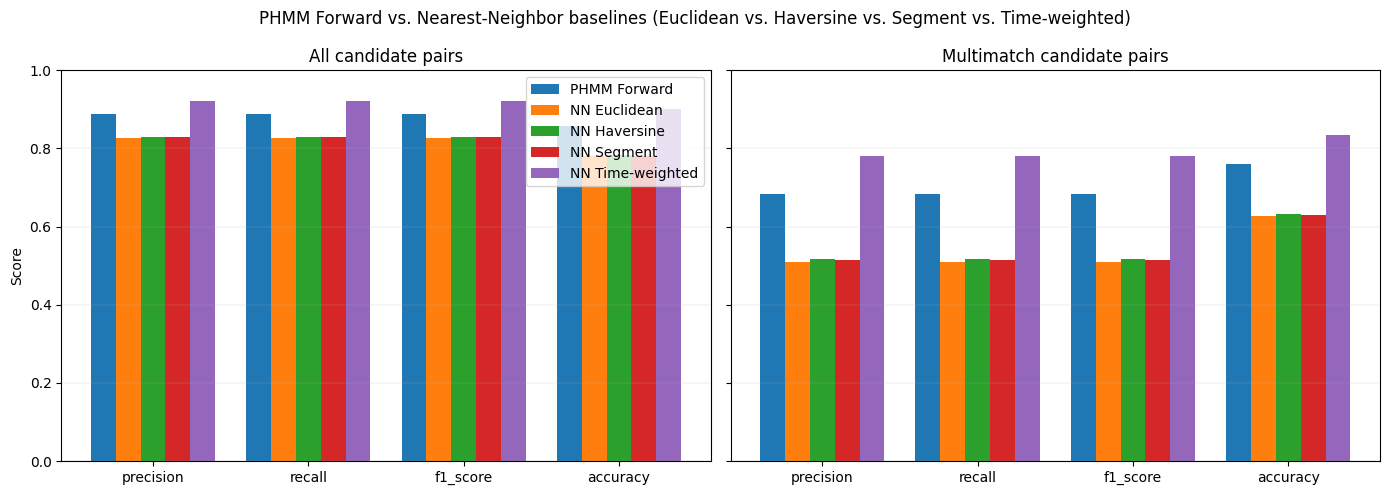

In [9]:
metric_cols = ["precision", "recall", "f1_score", "accuracy"]
x = np.arange(len(metric_cols))
n_models = len(MODELS)
width = 0.8 / n_models

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, comparison, title in zip(
    axes, [comparison_all, comparison_multimatch], ["All candidate pairs", "Multimatch candidate pairs"]
):
    for i, (name, _, _, _, _) in enumerate(MODELS):
        offset = (i - (n_models - 1) / 2) * width
        ax.bar(x + offset, comparison.loc[name, metric_cols], width, label=name)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_cols)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.grid(True, axis="y", linewidth=0.15)

axes[0].set_ylabel("Score")
axes[0].legend()
fig.suptitle("PHMM Forward vs. Nearest-Neighbor baselines (Euclidean vs. Haversine vs. Segment vs. Time-weighted)")
plt.tight_layout()
plt.show()